# Chapter 11.1 -- Unsupervised Learning and Clustering

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Chapters 9 and 10 learned from data that carried the answer in a column. This part removes that column: the data is only the measurements, and the method has to find the groups on its own. It defines unsupervised learning, says what clustering is for in a business, and applies Chapter 9's two clustering methods -- K-means and hierarchical clustering -- to a real dataset with scikit-learn and SciPy. Part 11.2 turns to association rules.

**In this chapter:** Labeled and unlabeled data · Clustering · Customer segmentation · The meaning of K · K-means with scikit-learn · Standardizing before clustering · The elbow and the silhouette · Hierarchical clustering with SciPy · Cutting a dendrogram · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Tell labeled from unlabeled data** and say what unsupervised learning looks for in the second.
> - **Say what clustering is for** -- customer segmentation, behavior grouping, product grouping.
> - **Run K-means with a library** after standardizing the data, explain what K is, and choose it with the elbow and the silhouette score.
> - **Build and cut a dendrogram** with SciPy, and check a clustering against a label it never saw.



**Contents**

- **11.1.1 · Unsupervised learning** — labeled and unlabeled data
- **11.1.2 · Clustering, in the real world** — grouping similar records, and three business uses
- **11.1.3 · K-means -- recap, and the iris flowers** — the meaning of K, the tool, then a real dataset
- **11.1.4 · Hierarchical clustering -- recap, and cutting the tree** — the tool, and two ways to cut
- **11.1.5 · Glossary** — the new terms of this part
- **11.1.6 · Where this part leaves us** — from groups of rows to items bought together
- **11.1.7 · Homework** — the graded work, on 178 wines



> **How to use this notebook.** Each idea below is explained first, then run in code one step per cell: the text above a code cell says what the cell does and why, and the Interpretation just under it reads the result. A recap of a Chapter 9 idea restates the definition and its worked numbers in one cell before moving on to what is new here.



#### Setup

Every cell below assumes these three libraries and this fixed random seed are already loaded.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(888102)
print("numpy", np.__version__, "· pandas", pd.__version__, "· ready")

numpy 2.5.3 · pandas 3.0.6 · ready


## 11.1.1 · Unsupervised learning

*labeled and unlabeled data*

**Unsupervised learning** learns from data that carries no label: no answer column, nothing marked as correct. The method sees only the features and looks for patterns or groups in them. Chapter 9 named three kinds of machine learning -- supervised, unsupervised and reinforcement learning -- and Chapter 10 spent three parts on the first. This part and Part 11.2 are the second.

|  | Supervised learning (Chapters 9, 10) | Unsupervised learning (Chapter 11) |
|---|---|---|
| **The data** | **Labeled**: every record has features and the answer -- species, played or not, sale price. | **Unlabeled**: every record has features only. |
| **The question** | Predict the answer for a new record. | Find the structure already in the records: groups, or items that go together. |
| **How it is checked** | Compare predictions with the true answers of a test set: accuracy, precision, recall, R². | There is no true answer to compare with. The result is judged by how tight the groups are and whether they make sense to a person. |
| **In this course** | Decision tree (10.1, 10.2), linear regression (10.3). | K-means, hierarchical clustering (11.1); association rules (11.2). |



#### Why a business often has no label

A store knows what each customer bought, not which type of customer they are: nobody wrote that down, and there may be no agreed set of types to begin with. Unsupervised learning proposes the types from the purchases.

> **The cost of having no label.** Without an answer column there is no test set and no accuracy. A clustering method returns groups whether or not real groups exist, so reading the result -- and checking it against outside knowledge where some exists -- is part of the method, not an optional step.



#### Where Section 11.1.1 leaves us

The main unsupervised task, and the rest of this part, is clustering. Section 11.1.2 says what it is and what a business does with it.



## 11.1.2 · Clustering, in the real world

*grouping similar records, and three business uses*

**Clustering** puts records into groups, called **clusters**, so that records in the same cluster are more alike than records in different clusters. Nobody names the groups in advance; the method finds them from the features. Two records are alike when the {b('distance')} between their feature values is small -- the same straight-line distance Section 9.3.1 used to find nearest neighbors, and with the same need to standardize the features first.



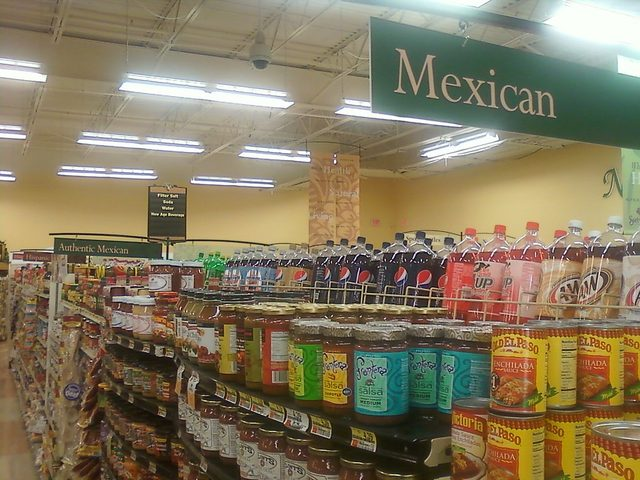

*Shelves organized by category are a clustering made by hand: items a shopper is likely to want together sit together. — Photo: sylvar, CC BY, via Flickr*



#### Three business uses

- **Customer segmentation** — Group customers by what they buy, how often and how much. Each segment gets its own offer -- a discount for one, a loyalty perk for another -- without anyone assigning customers by hand.
- **Customer behavior grouping** — Group by how customers use a service: time of day, device, features used, visits per week. The groups show which behaviors go together and which customers may leave.
- **Product grouping** — Group products by who buys them and when, rather than by the category on the label. Products that cluster together belong on the same shelf, page or promotion.

> **The output is a new column.** Whatever the method, its result is one more column in the table: the cluster number of every record. That column is what the business acts on, and, when a label does exist somewhere else, what the clustering is checked against.



#### Where Section 11.1.2 leaves us

Section 11.1.3 recaps the first clustering method Chapter 9 built, K-means, and applies it through scikit-learn to a real dataset.



## 11.1.3 · K-means -- recap, and the iris flowers

*the meaning of K, the tool, then a real dataset*



#### Recap -- the algorithm and what it minimizes

*Section 9.4.1*

> **Definition.** **K-means** sorts points into a chosen number of clusters $k$ by repeating two steps until nothing changes: assign every point to its nearest centroid, then move each centroid to the mean of its members. It is hard clustering -- every point ends up in exactly one cluster -- and it minimizes the total squared distance from every point to its own cluster's centroid, called the **inertia**, $J = \sum_{i=1}^{k} \sum_{\mathbf{x} \in C_i} \lVert \mathbf{x} - \boldsymbol{\mu}_i \rVert^2$. Chapter 9 grew this loop from scratch on 60 points around $(2,2)$ and $(7,7)$, chose $k=2$ by watching inertia bend at an elbow, and confirmed it with the silhouette score, which peaked at the same $k$.

Both figures below are the ones Section 9.4.1 built; they are shown again because everything that follows in this section still assumes them.



#### The loop

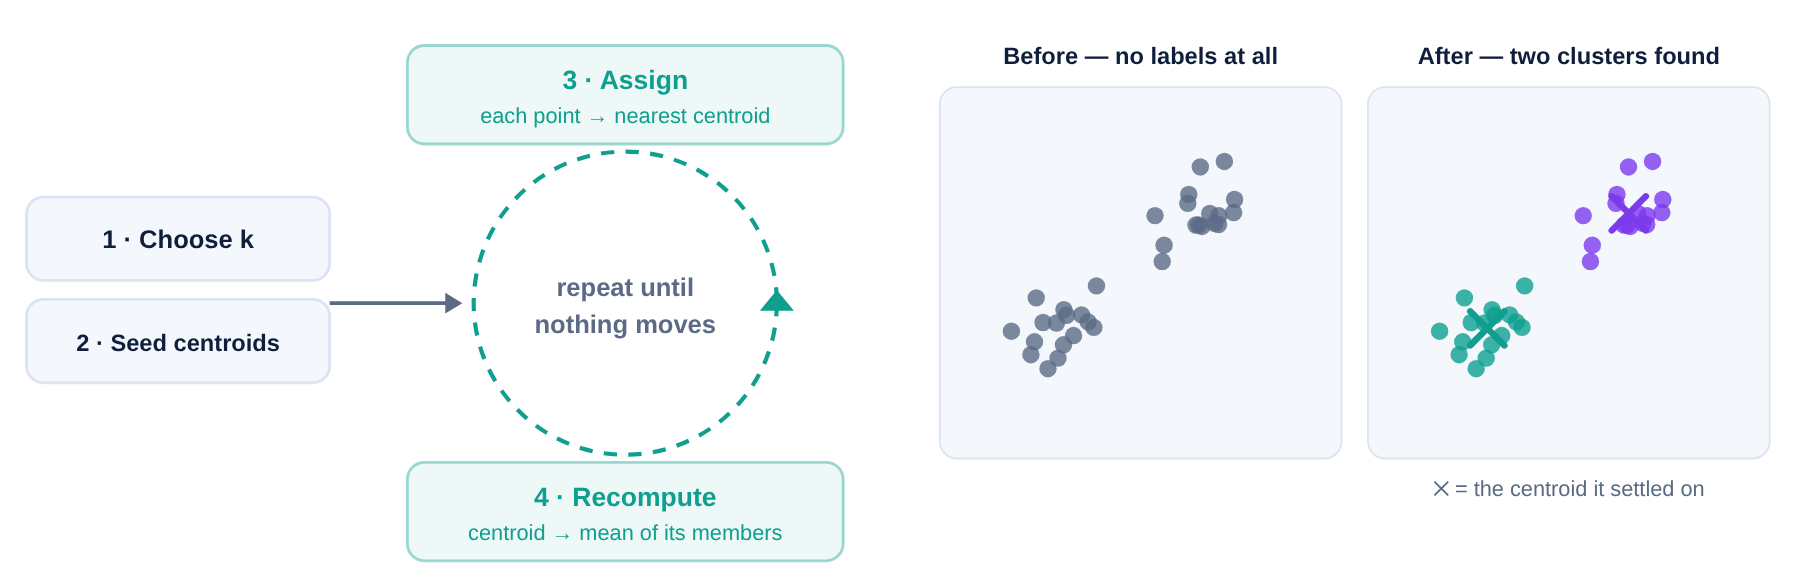

*Two steps, repeated. **You** pick k; the algorithm never questions it. Neither step can make the clusters worse, which is why the loop always comes to a stop.*



#### The meaning of K

**K is the number of clusters, and the user fixes it before K-means runs.** The method cannot choose it: it returns exactly the number of clusters it is asked for, whether or not that many real groups exist. On Chapter 9's 60 points, K = 1 forces the two real groups into one cluster, K = 2 gives each group its own centroid, and K = 4 cuts each real group in half. The data do not change between the three runs; only K does.

> **The K-means workflow.** The four steps of the loop, in the order the course names them: choose K -> assign every point to its nearest centroid -> calculate each centroid as the mean of its points -> reassign -> repeat until no point changes cluster.



#### Choosing k by two measures, together

| Measure | What it watches | How k is chosen |
|---|---|---|
| **Inertia (the elbow method)** | Total squared distance to each point's own centroid; always falls as $k$ rises. | Plot it against $k$ and take the point where the drop flattens -- the elbow. |
| **Silhouette score** | How much closer each point is to its own cluster than to the next-nearest one, from $-1$ to $1$. | A number to maximize; unlike inertia it does not always fall as $k$ rises. |

> **What neither measure promises.** Both measures answer a geometric question -- how tightly do the points pack for this $k$? -- and neither can say the groups are meaningful. K-means returns exactly the $k$ clusters it is asked for, whether or not $k$ real groups exist.



#### The steps

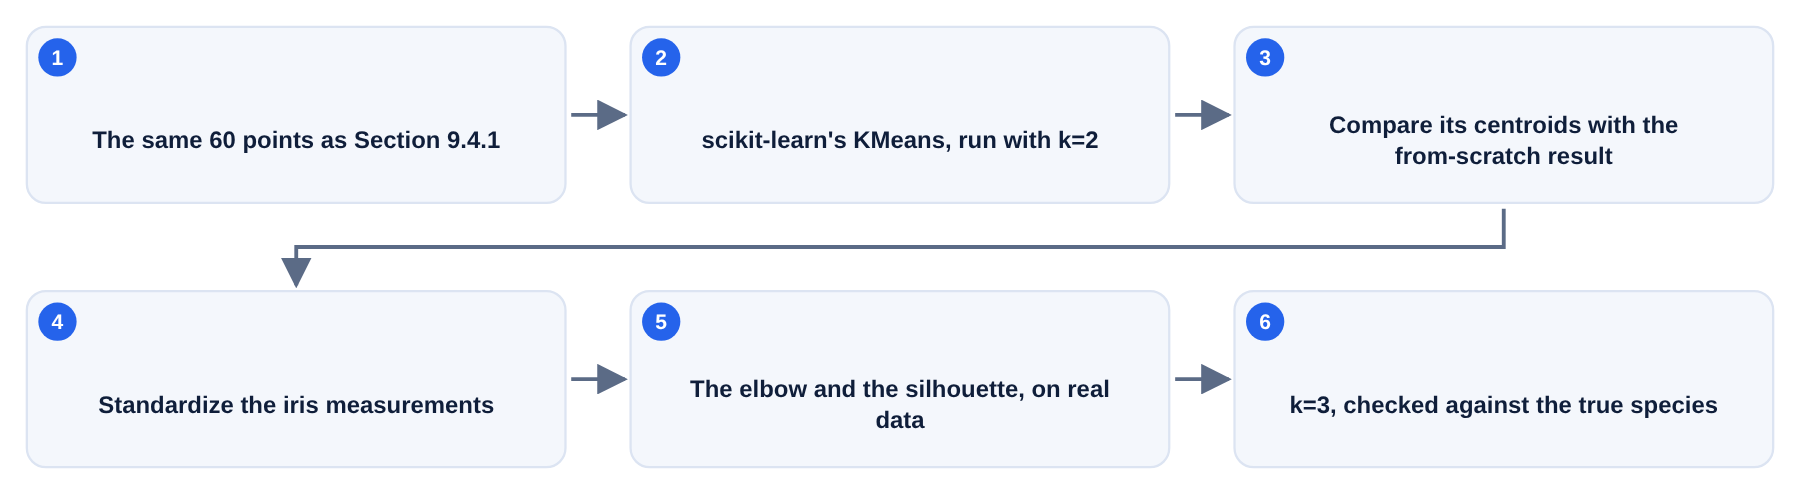

*Section 11.1.3's code walk: confirm the library against Section 9.4.1, then apply it to a dataset with no from-scratch answer to check against.*



#### The same 60 points

Section 9.4.1's two groups of 30, drawn with the same center, spread and seed, so the library's answer can be checked against the from-scratch one.



In [2]:
group_1 = rng.normal(loc=(2, 2), scale=0.6, size=(30, 2))
group_2 = rng.normal(loc=(7, 7), scale=0.6, size=(30, 2))
points = np.vstack([group_1, group_2])
points.shape

(60, 2)

#### scikit-learn's KMeans

`KMeans(n_clusters=2, n_init=10, random_state=888102)` runs the same loop Section 9.4.1 wrote by hand -- assign, recompute, repeat -- and `n_init=10` simply runs it 10 times from different starting centroids and keeps the run with the smallest inertia, the safeguard Section 9.4.1 flagged as missing from a single from-scratch run.



> **Interpretation.** The two centroids sit close to $(2, 2)$ and $(7, 7)$ -- the same positions Section 9.4.1's own function found. `kmeans.inertia_` holds the $J$ this run settled on, the same quantity the elbow and silhouette below are computed from.



In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, n_init=10, random_state=888102)
kmeans.fit(points)
kmeans.cluster_centers_.round(2)

array([[2.04, 2.07],
       [6.89, 7.06]])

#### Where the tool changes what comes next

Every remaining cell in this section applies the library to a dataset with no from-scratch answer to check against: the 150 iris flowers already loaded in Section 10.1.7, this time with the species column set aside.



#### The iris flowers, unlabeled

`load_iris` is the same call Section 10.1.7 used to grow a tree; here only the four measurements are kept as X -- the species column is not shown to K-means at all. It is kept as y, so the clustering can be checked against it afterward, in Section 11.1.3's last cell.



> **Interpretation.** Petal length ranges roughly from 1 to 7, sepal width from 2 to 4.4 -- the four columns are not on the same scale, which matters as soon as a distance is computed between rows.



In [4]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X_iris = iris.data.copy()
X_iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
y_species = iris.target_names[iris.target]
X_iris.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


#### Standardizing before a distance

K-means measures distance the same way Section 9.3.1 did, and a distance treats every column as equally important. A column measured in centimeters with a wide range would dominate one measured over a narrower range, for no reason connected to which flowers are actually similar. `StandardScaler` rescales every column to mean 0 and standard deviation 1, so all four measurements start on equal footing.



> **Interpretation.** Every column now has mean 0.00 and standard deviation 1.00 (up to rounding). Distances computed on this table weigh all four measurements the same way.



In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)
pd.DataFrame(X_scaled, columns=X_iris.columns).describe().round(2).loc[["mean", "std"]]

,sepal_length,sepal_width,petal_length,petal_width
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


#### The elbow, on real data

Inertia is recorded for k = 1 to 8, exactly as Section 9.4.1 did on the toy points, this time on the scaled iris measurements.



In [6]:
inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=888102).fit(X_scaled)
    inertias.append(km.inertia_)
pd.DataFrame({"k": range(1, 9), "inertia": np.round(inertias, 1)})

,k,inertia
0,1,600.0
1,2,222.4
2,3,140.0
3,4,114.3
4,5,90.8
5,6,80.7
6,7,71.6
7,8,62.6


#### The elbow, drawn

The same chart shape as Section 9.4.1's elbow figure, this time on the iris data.



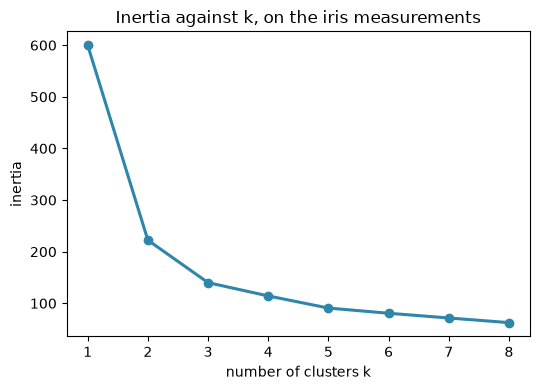

In [7]:
plt.figure(figsize=(5.5, 4))
plt.plot(range(1, 9), inertias, marker="o", linewidth=2.2, color="#2E86AB")
plt.xlabel("number of clusters k")
plt.ylabel("inertia")
plt.title("Inertia against k, on the iris measurements")
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** Reading the elbow:
>
> - The drop from k=1 to k=2 is by far the largest single step.
> - A smaller bend follows around k=3, then the curve flattens further.
> - Unlike the toy points, there is no single unmistakable elbow -- real data rarely bends as cleanly as a dataset built to have exactly two groups.



#### The silhouette, on real data

`silhouette_score` from scikit-learn is the same quantity Section 9.4.1 wrote by hand, computed for k = 2 through 6 (a silhouette needs at least two clusters).



> **Interpretation.** The silhouette is highest at k=2, not k=3 -- even though the flowers actually come from three species. Section 9.4.1's warning applies exactly here: geometry says two tight groups; only outside knowledge (the species label) says there are three.



In [8]:
from sklearn.metrics import silhouette_score

silhouettes = []
for k in range(2, 7):
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=888102).fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels_k))
pd.DataFrame({"k": range(2, 7), "silhouette": np.round(silhouettes, 3)})

,k,silhouette
0,2,0.582
1,3,0.463
2,4,0.388
3,5,0.346
4,6,0.340


#### k=3, checked against the species label

K-means is run with `k=3` anyway, to match the three known species, and its cluster numbers are cross-tabulated against the species column that was never shown to it.



> **Interpretation.** Reading the table:
>
> - One cluster holds all 50 setosa flowers and nothing else -- the geometric separation the elbow's first, largest drop already hinted at.
> - The other two clusters mostly separate versicolor from virginica, but 28 of the 100 flowers from those two species land in the other species' cluster -- the overlap the silhouette's preference for k=2 was picking up on.
> - K-means never saw the word setosa or virginica; the agreement comes entirely from the four measurements.



In [9]:
labels_3 = KMeans(n_clusters=3, n_init=10, random_state=888102).fit_predict(X_scaled)
pd.crosstab(pd.Series(y_species, name="species"), pd.Series(labels_3, name="cluster"))

cluster,0,1,2
species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,17,0,33


#### The clusters, drawn against the true species

Two panels on the same two measurements -- petal length (cm) and petal width (cm), the pair Section 10.1.7 found the tree's questions relied on most: left, colored by the k=3 clusters; right, colored by the true species.



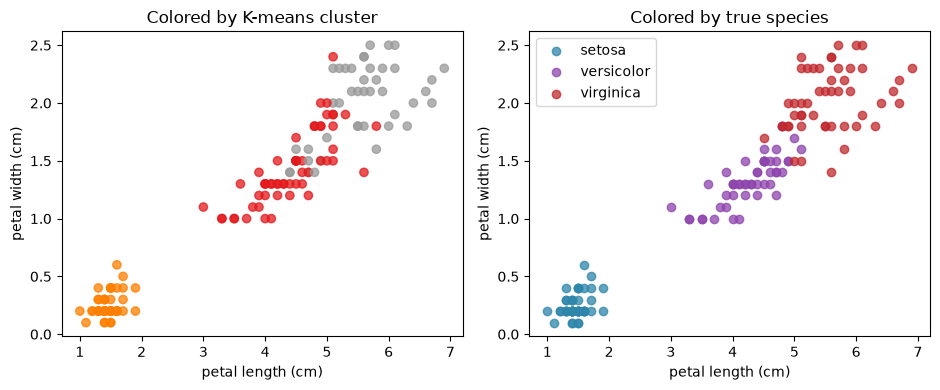

In [10]:
fig, (ax_c, ax_s) = plt.subplots(1, 2, figsize=(9.5, 4))
ax_c.scatter(X_iris["petal_length"], X_iris["petal_width"], c=labels_3, cmap="Set1", alpha=0.75)
ax_c.set_xlabel("petal length (cm)")
ax_c.set_ylabel("petal width (cm)")
ax_c.set_title("Colored by K-means cluster")
for name, color in zip(iris.target_names, ["#2E86AB", "#8E44AD", "#C1292E"]):
    mask = y_species == name
    ax_s.scatter(X_iris.loc[mask, "petal_length"], X_iris.loc[mask, "petal_width"], color=color,
                 alpha=0.75, label=name)
ax_s.set_xlabel("petal length (cm)")
ax_s.set_ylabel("petal width (cm)")
ax_s.set_title("Colored by true species")
ax_s.legend()
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** The two panels:
>
> - **Left panel -- the clusters** show the same three-way shape as the right panel, with the boundary between the two crowded groups drawn in a slightly different place than the true species boundary.
> - **Right panel -- the true species** confirms setosa (bottom left) sits apart from the other two, which overlap along the petal measurements.
> - The clustering found real structure in the data; it is not a perfect match to species because the measurements themselves overlap between versicolor and virginica.



#### Where Section 11.1.3 leaves us

K-means, applied through a library, standardized first, chose a number of clusters by two geometric measures and checked, only afterward, against a label it never used while clustering. Section 11.1.4 recaps the second Chapter 9 method and applies it the same way.



## 11.1.4 · Hierarchical clustering -- recap, and cutting the tree

*the tool, and two ways to cut*



#### Recap -- linkage and the dendrogram

*Section 9.4.2*

> **Definition.** **Hierarchical clustering** builds a whole tree of clusters instead of committing to one $k$: every point starts alone, and at each step the two closest clusters merge, until one cluster remains. That tree is a **dendrogram**. “Closest” between two clusters, rather than two points, is defined by a **linkage** -- Section 9.4.2 covered single (nearest pair), complete (furthest pair) and average (mean over every pair), and used average linkage throughout.

The worked example was five points -- a(0,0), b(0,1), c(5,5), d(5,6), e(6,5) -- which merged in this order under average linkage:

| Step | Merge | Distance |
|:-:|:--|--:|
| **1** | a + b | 1.00 |
| **2** | c + d | 1.00 |
| **3** | e + (c+d) | 1.21 |
| **4** | (a+b) + (e+c+d) | 7.23 |



#### Linkages

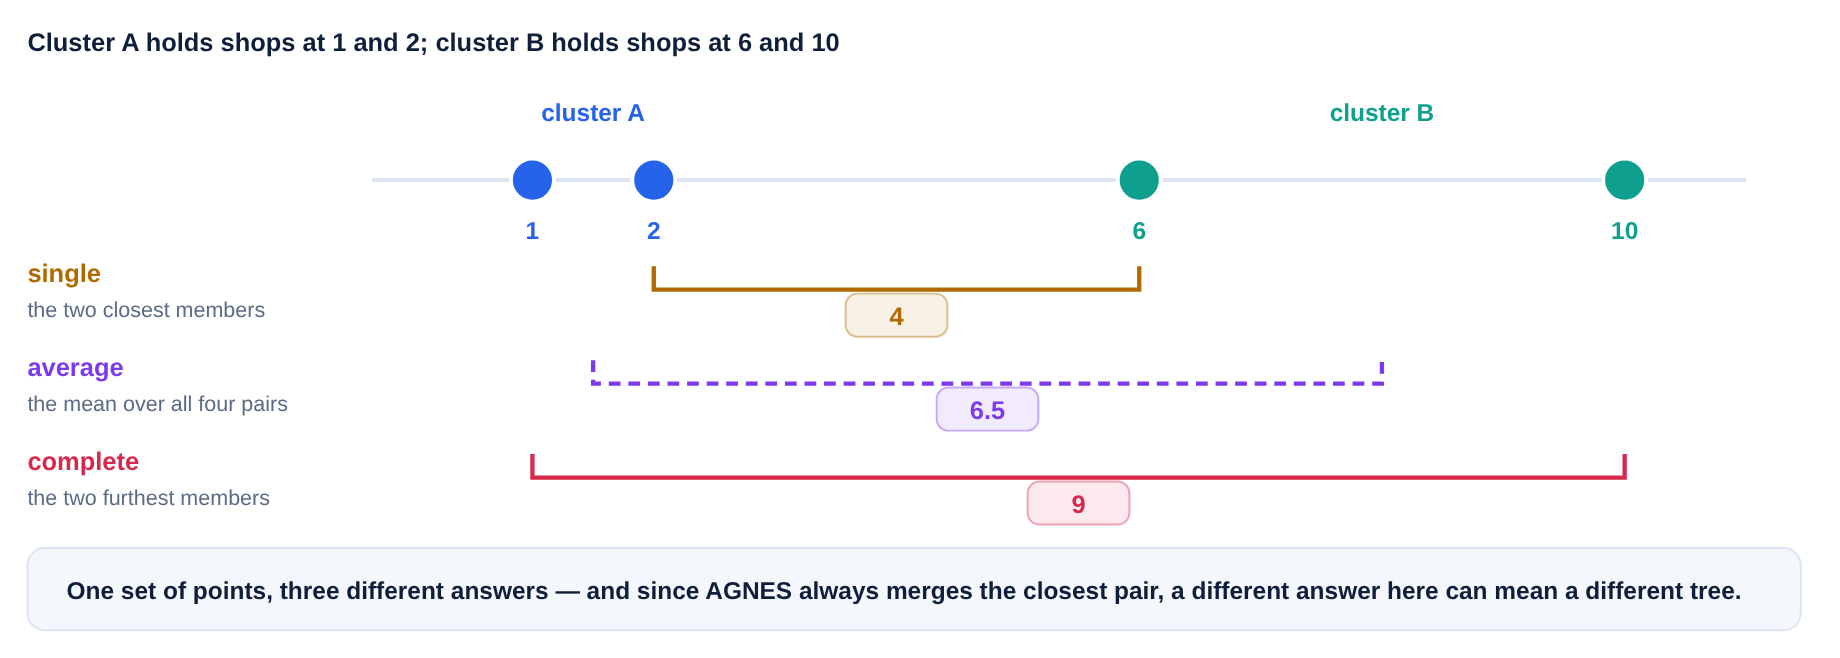

*All three linkages read the same four pairwise distances. They differ only in what they do with the list: take the smallest, the largest, or the average.*



#### The steps

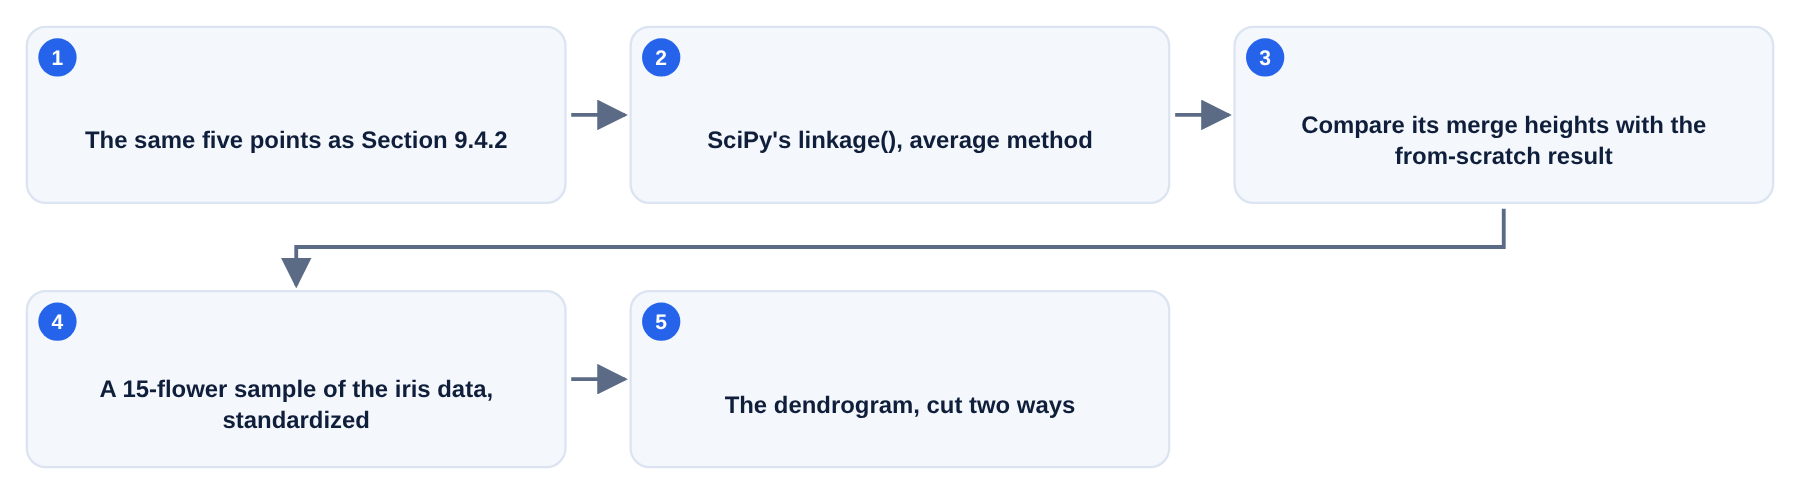

*Section 11.1.4's code walk: confirm SciPy against Section 9.4.2, then cut a real dendrogram by a distance and by a cluster count.*



#### The same five points

Section 9.4.2's tiny_points dictionary, unchanged.



In [11]:
tiny_points = {"a": (0, 0), "b": (0, 1), "c": (5, 5), "d": (5, 6), "e": (6, 5)}
coords = np.array(list(tiny_points.values()))
coords

array([[0, 0],
       [0, 1],
       [5, 5],
       [5, 6],
       [6, 5]])

#### SciPy's linkage()

`linkage(coords, method="average")` runs the merge-the-closest-pair loop Section 9.4.2 wrote by hand, and returns one row per merge: the two cluster IDs merged, the distance at which they merged, and the size of the new cluster.



> **Interpretation.** The distance column reads 1.00, 1.00, 1.21, 7.23 -- the same four merge distances Section 9.4.2's own loop printed, in the same order.



In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

merge_log = linkage(coords, method="average")
pd.DataFrame(merge_log, columns=["cluster 1", "cluster 2", "distance", "size"]).round(2)

,cluster 1,cluster 2,distance,size
0,0.0,1.0,1.00,2.0
1,2.0,3.0,1.00,2.0
2,4.0,6.0,1.21,3.0
3,5.0,7.0,7.23,5.0


#### The dendrogram, from the library

`dendrogram()` draws the same tree Section 9.4.2 drew by hand from the merge log, with the leaf labels supplied.



> **Interpretation.** The same shape as Section 9.4.2's hand-drawn tree: a and b join low, c/d/e join low, and the two groups join only at the tall final merge.



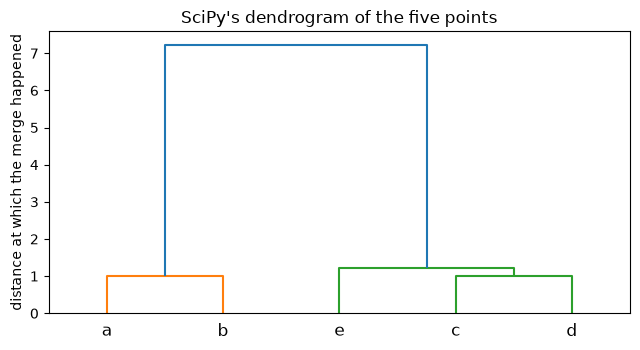

In [13]:
plt.figure(figsize=(6.5, 3.6))
dendrogram(merge_log, labels=list(tiny_points.keys()))
plt.ylabel("distance at which the merge happened")
plt.title("SciPy's dendrogram of the five points")
plt.tight_layout()
plt.show()

#### Cutting the tree, two ways

| Way to cut | SciPy call | What you supply |
|---|---|---|
| **By distance** | `fcluster(merge_log, t=4.0, criterion="distance")` | A threshold height. Every merge above it is undone; every merge at or below it stands. |
| **By cluster count** | `fcluster(merge_log, t=2, criterion="maxclust")` | The number of clusters wanted. SciPy finds the cut height that produces exactly that many. |

> **Why the two usually agree.** Both give the same answer on the five-point example, because both roads lead to the one large gap between 1.21 and 7.23: cutting at any height in that gap, or asking for exactly 2 clusters, undoes only the last merge. On messier data the two are not always identical, because a chosen cluster count can force a cut through a merge that a distance threshold would have left alone.



#### Cutting by distance

A threshold of `t=4.0` falls inside the 1.21-to-7.23 gap Section 9.4.2 identified as the natural place to cut.



In [14]:
fcluster(merge_log, t=4.0, criterion="distance")

array([1, 1, 2, 2, 2], dtype=int32)

#### Cutting by cluster count

Asking directly for two clusters.



> **Interpretation.** Both cuts return the same grouping: a and b together, c, d and e together -- Section 9.4.2's two clusters, reached two different ways.



In [15]:
fcluster(merge_log, t=2, criterion="maxclust")

array([1, 1, 2, 2, 2], dtype=int32)

#### A real dendrogram needs a small sample

Section 9.4.2's advantage of hierarchical clustering -- see the whole tree, decide the cut afterward -- has a cost: comparing every pair of clusters at every step makes a dendrogram of all 150 iris flowers too dense to read on one page. The first 5 flowers of each of the three species, 15 in total, keep every merge visible while still drawing from real data.



#### A 15-flower sample, standardized

`groupby("species").head(5)` keeps the first 5 flowers of each species, and the same StandardScaler as Section 11.1.3 puts the four measurements on equal footing before any distance is computed.



In [16]:
sample = X_iris.assign(species=y_species).groupby("species").head(5).reset_index(drop=True)
X_sample_scaled = StandardScaler().fit_transform(sample.drop(columns="species"))
sample["species"].value_counts()

species
setosa        5
versicolor    5
virginica     5
Name: count, dtype: int64

#### The dendrogram of the sample

Average linkage, as above, on the 15 standardized flowers. The leaf labels are the true species, kept here only to read the tree afterward -- the clustering itself never sees them.



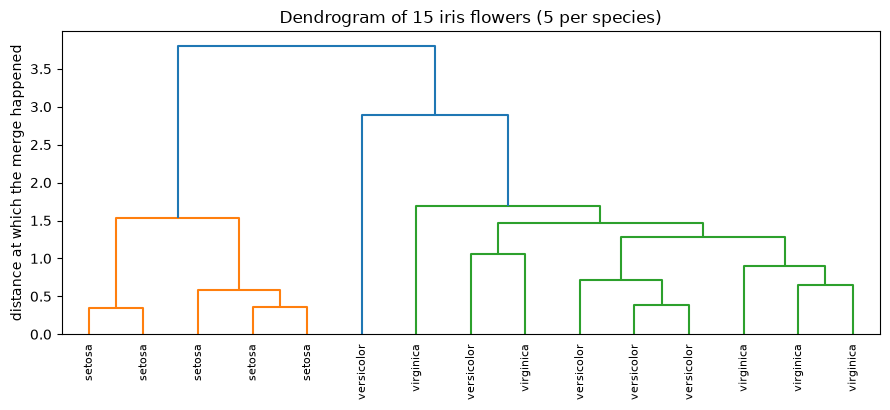

In [17]:
sample_log = linkage(X_sample_scaled, method="average")
plt.figure(figsize=(9, 4.2))
dendrogram(sample_log, labels=list(sample["species"]), leaf_rotation=90, leaf_font_size=8)
plt.ylabel("distance at which the merge happened")
plt.title("Dendrogram of 15 iris flowers (5 per species)")
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** Reading the tree:
>
> - The five setosa leaves merge into one tight branch, well separated from the rest -- the same separation Section 11.1.3's cluster-against-species table found.
> - Versicolor and virginica leaves are interleaved on the other branch, joining each other before that branch finally joins setosa's at the tallest merge.



#### Cutting the sample for 3 clusters

Asking `fcluster` for 3 clusters, the number of species, and cross-tabulating the clusters against the species the tree never saw.



> **Interpretation.** Reading the table:
>
> - **Cluster 1 is exactly the 5 setosa flowers.**
> - **Cluster 2 holds 4 versicolor and all 5 virginica** -- the two species the tree could not separate.
> - **Cluster 3 is one versicolor flower on its own**: the third cluster went to an outlier, not to a species. A clustering answers a geometric question, and the species line is not where the geometry puts it.



In [18]:
clusters3 = fcluster(sample_log, t=3, criterion="maxclust")
pd.crosstab(sample["species"], pd.Series(clusters3, name="cluster"))

cluster,1,2,3
species,,,
setosa,5,0,0
versicolor,0,4,1
virginica,0,5,0


#### Where Section 11.1.4 leaves us

Both Chapter 9 clustering methods now run through a library, standardized first, on a real dataset, and both agree with each other and with Section 11.1.3's K-means result: setosa is easy, versicolor and virginica overlap. K-means asked for K first; hierarchical clustering built the whole tree and left the number of clusters to the cut. Part 11.2 asks a different question of a store's data: not which rows resemble each other, but which items tend to be bought together.



## 11.1.5 · Glossary

*the new terms of this part*

K-means, inertia, the elbow, the silhouette score, hierarchical clustering, linkage and the dendrogram are defined in Chapter 9's own glossary (Section 9.4) and are not repeated here. This table holds only the vocabulary Part 11.1 adds.

| Term | Meaning |
|---|---|
| **Labeled / unlabeled data** | Records that carry the answer column, or records that carry features only. |
| **Customer segmentation** | Grouping customers by behavior or preference, with clustering, so each group can be treated differently. |
| **K (in K-means)** | The number of clusters, fixed by the user before the method runs. |
| **Standardizing (scaling)** | Rescaling every feature to mean 0 and standard deviation 1, so a distance-based method weighs all of them equally. |
| **Cutting a dendrogram** | Choosing where to stop merging, by a distance threshold or by a wanted number of clusters. |
| **Cluster validation against a label** | Comparing a clustering's groups with a label the method never used, as a check -- not proof -- that the groups are meaningful. |



## 11.1.6 · Where this part leaves us

*from groups of rows to items bought together*

- **Unsupervised learning** finds structure in data with no answer column, and its result is read and judged by a person, or checked against a label kept aside.
- **K-means** needs K first; it was chosen here with the elbow and the silhouette score, which on the iris flowers preferred 2 clusters to the 3 species.
- **Hierarchical clustering** builds the whole tree first and leaves the number of clusters to the cut.

> **Next: association rules.** Clustering grouped the rows of a table. Part 11.2 asks a different question of a store's receipts: which items tend to be in the same basket, how often, and whether the pattern is worth acting on.



## 11.1.7 · Homework

*the graded work, on 178 wines*

The exercises continue Sections 11.1.3 and 11.1.4 on a new real dataset, in the order this part taught the ideas: standardize, choose K, cluster and check, cut a dendrogram, and tell supervised from unsupervised problems. Each exercise has a code cell for your work and a text cell for your answer.

**Student information** -- double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework data -- 178 wines

*run this cell, but do not modify it*

Run this cell once and do not edit it. It loads `X_wine` (13 chemical measurements) and `y_wine` (the true grower, 0/1/2, not to be used until Exercise 2).



In [19]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X_wine = wine.data.copy()
y_wine = wine.target
print("X_wine:", X_wine.shape)
X_wine.head(3)

X_wine: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


#### Exercise 1 — Standardize and choose K

Standardize `X_wine` with `StandardScaler`, as Section 11.1.3 did for the iris flowers. Compute the inertia for K = 1 to 8 and the silhouette score for K = 2 to 6 (both with `random_state=888102`). Which K does each measure point to, and do they agree with each other?



In [20]:
# YOUR CODE HERE (Exercise 1)

#### Your answer -- Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — Cluster and validate

Run `KMeans` with `n_clusters=3` on the standardized wines (to match the three known growers) and cross-tabulate the cluster numbers against `y_wine`, the same way Section 11.1.3 checked the iris clusters against species. How many wines does the clustering place with the wrong grower?



In [21]:
# YOUR CODE HERE (Exercise 2)

#### Your answer -- Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — A dendrogram of a sample

Take the first 6 wines of each grower (18 in all, with `groupby(...).head(6)`), standardize them, and draw their dendrogram with average linkage, as Section 11.1.4 did for the 15-flower sample. Cut it for 3 clusters with `fcluster(..., criterion="maxclust")` and say whether the cut recovers the three growers.



In [22]:
# YOUR CODE HERE (Exercise 3)

#### Your answer -- Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — Supervised or unsupervised?

For each scenario, say whether it is a supervised or an unsupervised problem, and why: (a) a streaming service groups its thirty thousand viewers into eight audience types; (b) a bank predicts whether a loan applicant will repay, from past loans whose outcome is known; (c) a store sorts its products into groups by who buys them, with no categories given in advance.



In [23]:
# YOUR CODE HERE (Exercise 4)

#### Your answer -- Exercise 4

*Double-click this cell and type your answer here.*



#### Bonus -- single against complete linkage

Using the same 18-wine sample as Exercise 3, draw two more dendrograms with `linkage(..., method="single")` and `linkage(..., method="complete")`. Compare the three shapes (average, single, complete) and say which one produces the most visibly uneven cluster sizes, tying your answer back to Section 9.4.2's description of what each linkage tends to do.



In [24]:
# YOUR CODE HERE (Bonus)

#### Your answer -- the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 4 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime -> Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

